# 10 · Deep Learning

Neural networks promise something none of our earlier models offer: **learning the features themselves**. Instead of us deciding that yesterday's value, the 7-day mean and the evening wind are what matter, a recurrent network reads the raw recent history and works out what to pay attention to.

Deep learning for forecasting is also where tutorials most often go wrong. Common mistakes include unscaled inputs, a single hand-picked test window, no baseline, tuning on the test period, and one training run reported as *the* result. This chapter avoids all of them, and gives neural networks a fair, carefully validated chance on the same task as every other model.

**By the end of this chapter you will be able to**

- turn a series into the **(samples, timesteps, features)** windows that sequence models expect, without leaking the future
- scale inputs using **training data only**, and stop training early using a **time-ordered validation** split
- build and train an **MLP**, a **SimpleRNN** and an **LSTM** that forecast all horizons at once
- measure **run-to-run variability** across random seeds, and reduce it by **ensembling**
- separate "better model" from "better inputs" with a like-for-like comparison, and judge when deep learning is worth it
- apply the same discipline to an **hourly, next-24-hours** task with far more data

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")         # hide TensorFlow's start-up messages
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")         # deterministic CPU arithmetic across runs

import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers
from sklearn.linear_model import Ridge

import tsutils

logging.getLogger("tensorflow").setLevel(logging.ERROR)     # e.g. the "no GPU on native Windows" notice

tsutils.set_style()
pd.set_option("display.precision", 3)

daily = tsutils.load_daily_pm25()
y, actual = daily["pm25"], daily["actual"]
weather = tsutils.load_daily_weather()
origins, H = tsutils.BACKTEST_ORIGINS, tsutils.HORIZON
print("Keras", keras.__version__)

Keras 3.15.1


---
## 1. From a series to windows

A sequence model takes, at each forecast origin, the last $L$ days of **raw inputs**, one row of features per day, and outputs forecasts for the next 7 days **in one go**. Producing all horizons at once from one model is called the **multi-output** (or MIMO) strategy. It's a middle ground between chapter 09's direct approach (one model per horizon) and the recursive approach.

Each day's input row contains:
- **log PM2.5** that day
- **that day's weather**, the eight features known by the end of the day (chapter 07's approach C)
- the **season**, as sine and cosine of the day of the year

So a single training example is a matrix of shape $L \times 11$, and a batch of them is a 3-D array of shape **(samples, timesteps, features)**. We use $L = 28$ days.

In [2]:
L = 28

inputs = pd.concat([np.log(y).rename("log_pm25"), weather[tsutils.KNOWN_TODAY_WEATHER]], axis=1)
doy = inputs.index.dayofyear.to_numpy()
inputs["season_sin"] = np.sin(2 * np.pi * doy / 365.25)
inputs["season_cos"] = np.cos(2 * np.pi * doy / 365.25)

values = inputs.to_numpy(dtype=float)
log_actual = np.log(actual).to_numpy()          # NaN on unscorable days: never used as targets

def window_at(position):
    """The L days of inputs ending on (and including) `position`."""
    return values[position - L + 1: position + 1]

def training_windows(refit_date):
    """All windows whose 7 targets were known by `refit_date`, dropping any with a missing target."""
    last_end = inputs.index.get_loc(refit_date) - H         # targets end on the refit date at the latest
    ends = np.arange(L - 1, last_end + 1)
    X = np.stack([window_at(p) for p in ends])
    Y = np.stack([log_actual[p + 1: p + 1 + H] for p in ends])
    complete = ~np.isnan(Y).any(axis=1)
    return X[complete], Y[complete]

X_example, Y_example = training_windows(pd.Timestamp("2013-12-31"))
print("inputs X:", X_example.shape, " targets Y:", Y_example.shape)

inputs X: (1183, 28, 11)  targets Y: (1183, 7)


About 1,180 examples, each a 28 × 11 matrix with 7 targets. It's fewer than the number of days, because a window is dropped if **any** of its 7 target days is unscorable. Note also the cut-off in `training_windows`: a window may only be used for training if all 7 of its targets had been observed by the refit date. That's chapter 09's trap 3, handled in the same way.

---
## 2. Scaling, validation and early stopping

Neural networks train badly on inputs with wildly different scales (humidity in the tens, wind shares between 0 and 1), so we **standardise** every input feature and the targets. The means and standard deviations come from the **training windows only**. Computing them over all the data would leak the future's typical level into the model.

We also need to decide **when to stop training**. We hold out the most recent 20% of the training windows as a **validation set**. It's time-ordered, so the model is validated on the period right after the one it learned from. Training stops once validation error hasn't improved for 15 passes through the data (*epochs*), and the best weights are restored. This is **early stopping**, the main defence against overfitting.

In [3]:
class Scaler:
    """Standardise inputs per feature and targets overall, using statistics from the training data only."""
    def fit(self, X, Y):
        flat = X.reshape(-1, X.shape[-1])
        self.x_mean, self.x_std = flat.mean(axis=0), flat.std(axis=0) + 1e-9
        self.y_mean, self.y_std = Y.mean(), Y.std()
        return self
    def x(self, X):
        return (X - self.x_mean) / self.x_std
    def y(self, Y):
        return (Y - self.y_mean) / self.y_std
    def y_back(self, Y_scaled):
        return Y_scaled * self.y_std + self.y_mean


def train(build_model, X, Y, seed, max_epochs=300, patience=15):
    """Fit one network with a time-ordered validation split and early stopping."""
    keras.utils.set_random_seed(seed)                 # seeds Python, NumPy and TensorFlow together
    scaler = Scaler().fit(X, Y)
    Xs, Ys = scaler.x(X), scaler.y(Y)
    n_val = int(len(Xs) * 0.2)
    model = build_model(X.shape[1:])
    history = model.fit(Xs[:-n_val], Ys[:-n_val], validation_data=(Xs[-n_val:], Ys[-n_val:]),
                        epochs=max_epochs, batch_size=32, verbose=0,
                        callbacks=[keras.callbacks.EarlyStopping(patience=patience, restore_best_weights=True)])
    return model, scaler, history

---
## 3. Two architectures

**MLP (multi-layer perceptron).** Flatten the 28 × 11 window into 308 numbers, pass them through one hidden layer of 64 units, and output 7 values. It sees all the inputs but has no built-in notion that they're ordered in time.

**LSTM (long short-term memory).** A recurrent layer that reads the window **one day at a time**, carrying a hidden state forward. Learned *gates* decide at each step what to keep, what to forget and what to output. This lets it capture patterns such as "the last few days matter, and a wind shift yesterday matters more". After reading day 28, its final state feeds a layer that outputs 7 values.

Both use **dropout** (randomly silencing 20% of units during training) as extra regularisation, and are trained on **mean absolute error**, on the log scale, to match our metric.

In [4]:
def mlp(input_shape):
    inp = keras.Input(input_shape)
    x = layers.Flatten()(inp)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    model = keras.Model(inp, layers.Dense(H)(x))
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")
    return model

def lstm(input_shape):
    inp = keras.Input(input_shape)
    x = layers.LSTM(32)(inp)
    x = layers.Dropout(0.2)(x)
    model = keras.Model(inp, layers.Dense(H)(x))
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")
    return model

lstm(X_example.shape[1:]).summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,863 (22.90 KB)

 Trainable params: 5,863 (22.90 KB)

 Non-trainable params: 0 (0.00 B)

About 5,900 parameters for the LSTM, trained on about 950 examples (the other 20% are the validation set). That ratio is worth keeping in mind. Chapter 09's ridge models had about 27 coefficients each.

Here are the learning curves from one training run, the first quarter's model:

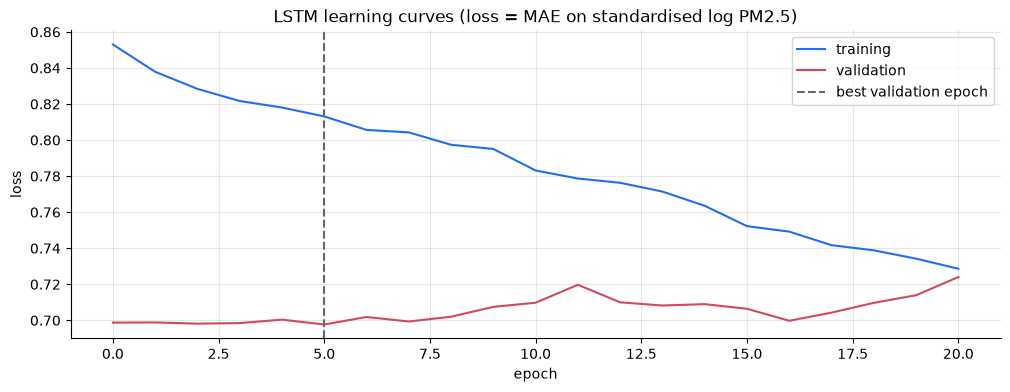

In [5]:
_, _, history = train(lstm, X_example, Y_example, seed=0)
curves = pd.DataFrame({"training": history.history["loss"], "validation": history.history["val_loss"]})
ax = curves.plot(title="LSTM learning curves (loss = MAE on standardised log PM2.5)", xlabel="epoch", ylabel="loss")
ax.axvline(curves["validation"].idxmin(), color="0.4", ls="--", label="best validation epoch")
ax.legend();

Training loss keeps falling, but **validation loss is almost flat from the very first epoch**. It reaches its best after about five epochs and then drifts upward. Almost everything the network learns after its first few passes through the data is specific to the training period, which is **memorisation**, not generalisable pattern. Early stopping keeps the best validation epoch and discards the rest. (Validation loss sits *below* training loss partly because dropout is only active during training, and partly because the validation period may simply be easier to forecast.) With this little data, there's very little to learn beyond the first few epochs.

---
## 4. The backtest, with five random seeds

Networks are refitted at the start of each **quarter** of 2014. That's less often than chapter 09's monthly refits, because training is slower, but the inputs are always the latest 28 days, so every forecast still uses up-to-date data. (Exercise 4 checks that refit frequency barely matters for a comparable ridge model.)

Training starts from random initial weights, so two runs on identical data give different models. We train the LSTM with **five seeds** and keep every seed's forecasts, both to measure that variability and to test the standard remedy: **average the ensemble**. The whole backtest takes a few minutes.

In [6]:
SEEDS = [0, 1, 2, 3, 4]
quarters = pd.Series(origins, index=origins).groupby(origins.quarter)

def network_backtest(build_model, seeds):
    """Quarterly refits; returns {seed: {(origin, h): forecast}}."""
    per_seed = {seed: {} for seed in seeds}
    for _, quarter_origins in quarters:
        X, Y = training_windows(quarter_origins.iloc[0])
        X_pred = np.stack([window_at(p) for p in inputs.index.get_indexer(quarter_origins.to_numpy())])
        for seed in seeds:
            model, scaler, _ = train(build_model, X, Y, seed)
            forecast = np.exp(scaler.y_back(model(scaler.x(X_pred), training=False).numpy()))
            for origin, row in zip(quarter_origins, forecast):
                per_seed[seed].update({(origin, h): row[h - 1] for h in range(1, H + 1)})
    return per_seed

def score(forecasts):
    lookup = lambda history, steps: np.array([forecasts[(history.index[-1], k)] for k in range(1, steps + 1)])
    return tsutils.evaluate(tsutils.backtest(y, lookup, origins, H, actuals=actual))

def ensemble(per_seed, seeds):
    keys = per_seed[seeds[0]].keys()
    return {key: np.mean([per_seed[s][key] for s in seeds]) for key in keys}

lstm_runs = network_backtest(lstm, SEEDS)
mlp_runs = network_backtest(mlp, [0])

In [7]:
seed_scores = pd.DataFrame({f"LSTM, seed {s}": score(lstm_runs[s])["MAE"] for s in SEEDS})
seed_scores["LSTM, 5-seed ensemble"] = score(ensemble(lstm_runs, SEEDS))["MAE"]
seed_scores["MLP, seed 0"] = score(mlp_runs[0])["MAE"]
seed_scores

,"LSTM, seed 0","LSTM, seed 1","LSTM, seed 2","LSTM, seed 3","LSTM, seed 4","LSTM, 5-seed ensemble","MLP, seed 0"
h,,,,,,,
1,49.803,46.160,49.052,44.739,48.524,46.711,50.316
2,56.647,59.521,54.816,54.414,57.355,55.466,62.551
3,56.648,60.607,55.683,55.852,59.812,56.595,63.474
4,57.084,62.399,55.600,56.930,57.946,57.009,61.905
5,56.994,63.569,56.174,57.361,58.246,57.350,62.589
6,56.585,61.518,55.944,57.083,57.045,56.690,60.610
7,56.931,60.295,55.557,56.353,56.584,56.461,58.516


**The same architecture, trained on the same data, gives noticeably different results depending only on the random seed.** The spread between the best and worst seed is several µg/m³ at some horizons, larger than most of the differences between *models* on our scoreboard. A single training run can make an LSTM look better or worse than it really is, and that's why reporting one run is one of the most common flaws in deep-learning forecasting studies.

**Averaging the five seeds** smooths out their idiosyncrasies. The ensemble is better than a typical individual seed at most horizons, and far more reproducible. The **MLP** does clearly worse than the LSTM. Flattening the window throws away the ordering, and with 308 inputs and one short series it overfits easily.

### The simplest recurrent network: SimpleRNN

The LSTM's gates exist to solve a specific problem. A plain recurrent layer updates its hidden state with a single formula, $h_t = \tanh(W x_t + U h_{t-1} + b)$. When it's trained, the signal from early time steps has to pass through that formula once per step. Over long sequences it tends to shrink towards zero (or blow up). This is the **vanishing (or exploding) gradient** problem, and it makes long memory hard to learn. LSTM gates give the network a protected path along which information can flow unchanged.

Does that matter here? Our windows are 28 steps, and PM2.5's memory is short. Let's train `SimpleRNN` with the same 32 units, five seeds and quarterly refits, and compare.

In [8]:
def simple_rnn(input_shape):
    inp = keras.Input(input_shape)
    x = layers.SimpleRNN(32)(inp)
    x = layers.Dropout(0.2)(x)
    model = keras.Model(inp, layers.Dense(H)(x))
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")
    return model

rnn_runs = network_backtest(simple_rnn, SEEDS)
pd.DataFrame({
    "LSTM, 5-seed ensemble": seed_scores["LSTM, 5-seed ensemble"],
    "SimpleRNN, 5-seed ensemble": score(ensemble(rnn_runs, SEEDS))["MAE"],
    "SimpleRNN, best single seed": pd.DataFrame({s: score(rnn_runs[s])["MAE"] for s in SEEDS}).min(axis=1),
    "SimpleRNN, worst single seed": pd.DataFrame({s: score(rnn_runs[s])["MAE"] for s in SEEDS}).max(axis=1),
})

,"LSTM, 5-seed ensemble","SimpleRNN, 5-seed ensemble","SimpleRNN, best single seed","SimpleRNN, worst single seed"
h,,,,
1,46.711,42.423,41.072,45.411
2,55.466,56.095,56.122,58.587
3,56.595,57.442,56.725,60.129
4,57.009,57.009,57.036,59.686
5,57.350,56.435,55.799,59.409
6,56.690,56.982,57.114,59.062
7,56.461,57.107,57.055,59.993


**Here the simpler network wins at day 1.** The SimpleRNN ensemble is clearly ahead of the LSTM ensemble for tomorrow, and its best single seed gets close to chapter 09's ridge. From day 2 on the two are level. Two reasons:

- **No long memory is needed.** PM2.5 forgets within days, so the vanishing-gradient problem that LSTM gates solve doesn't arise over these 28-step windows.
- **Fewer parameters.** SimpleRNN has about 1,400 against the LSTM's 5,600. With about 950 training examples, less capacity means less room to memorise the training period (section 2's learning curves).

The seed spread is again several µg/m³, so the ensemble matters as much as the architecture. An LSTM's extra machinery pays off for long-range dependencies, and this problem has almost none. Start with the simplest model that could work.

model,climatology (median),AR(2) on anomalies,"SARIMAX, today's weather","Ridge, direct","LSTM, 5-seed ensemble"
h,,,,,
1,56.079,46.803,40.937,40.187,46.711
2,56.561,55.419,55.956,54.082,55.466
3,56.771,56.264,56.834,56.391,56.595
4,57.133,56.533,56.809,56.233,57.009
5,57.099,56.587,56.687,55.832,57.350
6,57.132,56.491,56.634,55.905,56.690
7,57.068,56.407,56.545,56.557,56.461


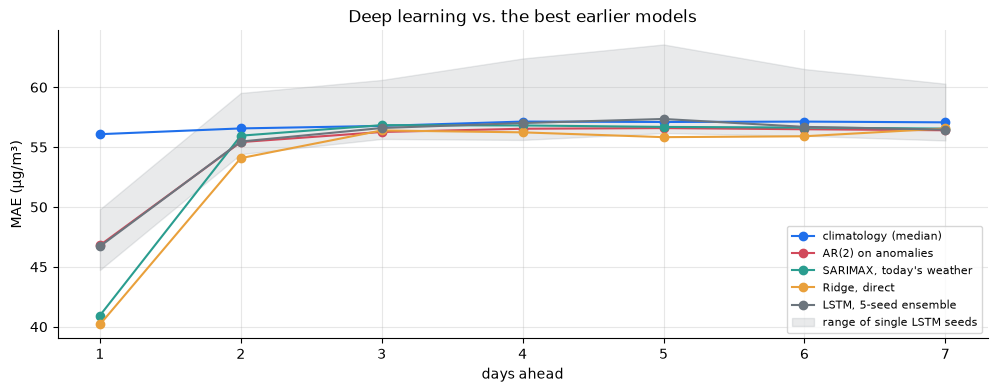

In [9]:
tsutils.save_scores("LSTM, 5-seed ensemble", score(ensemble(lstm_runs, SEEDS)))
tsutils.save_scores("MLP", score(mlp_runs[0]))
tsutils.save_scores("SimpleRNN, 5-seed ensemble", score(ensemble(rnn_runs, SEEDS)))

board = tsutils.load_scores().pivot(index="h", columns="model", values="MAE")
leaders = ["climatology (median)", "AR(2) on anomalies", "SARIMAX, today's weather", "Ridge, direct", "LSTM, 5-seed ensemble"]

fig, ax = plt.subplots()
for name in leaders:
    ax.plot(board.index, board[name], marker="o", label=name)
single_seeds = seed_scores.filter(like="LSTM, seed")
low, high = single_seeds.min(axis=1), single_seeds.max(axis=1)
ax.fill_between(board.index, low, high, color=tsutils.PALETTE[4], alpha=0.15, label="range of single LSTM seeds")
ax.set(title="Deep learning vs. the best earlier models", xlabel="days ahead", ylabel="MAE (µg/m³)")
ax.legend(fontsize=8)
board[leaders]

The ensemble LSTM lands at roughly the level of **chapter 06's AR(2)**. It has learned the one-day memory and the seasonal level from raw data, which is a genuine achievement for a model given no hand-made features. But it's **well behind chapter 09's ridge regression at days 1 and 2**, and from day 3 on everything converges to the same climatology-like level.

---
## 5. Better model, or better inputs?

Is ridge better because it's a better *model*, or because chapter 09 gave it better *inputs*? We can separate the two by giving ridge **exactly the LSTM's raw windows**, flattened, with the same quarterly refits and scaling.

In [10]:
def ridge_on_windows(columns):
    positions = [inputs.columns.get_loc(c) for c in columns]
    forecasts = {}
    for _, quarter_origins in quarters:
        X, Y = training_windows(quarter_origins.iloc[0])
        X = X[:, :, positions]
        scaler = Scaler().fit(X, Y)
        model = Ridge(alpha=10.0).fit(scaler.x(X).reshape(len(X), -1), scaler.y(Y))
        X_pred = np.stack([window_at(p) for p in inputs.index.get_indexer(quarter_origins.to_numpy())])[:, :, positions]
        forecast = np.exp(scaler.y_back(model.predict(scaler.x(X_pred).reshape(len(X_pred), -1))))
        for origin, row in zip(quarter_origins, forecast):
            forecasts.update({(origin, h): row[h - 1] for h in range(1, H + 1)})
    return forecasts

like_for_like = pd.DataFrame({
    "LSTM ensemble (raw windows)": seed_scores["LSTM, 5-seed ensemble"],
    "ridge on the same raw windows": score(ridge_on_windows(list(inputs.columns)))["MAE"],
    "ridge on the same windows, no weather": score(ridge_on_windows(["log_pm25", "season_sin", "season_cos"]))["MAE"],
    "ridge on chapter 09's features": board["Ridge, direct"],
})
like_for_like

,LSTM ensemble (raw windows),ridge on the same raw windows,"ridge on the same windows, no weather",ridge on chapter 09's features
h,,,,
1,46.711,43.016,47.478,40.187
2,55.466,58.526,55.661,54.082
3,56.595,60.668,56.349,56.391
4,57.009,60.620,56.280,56.233
5,57.350,60.335,56.465,55.832
6,56.690,59.834,56.561,55.905
7,56.461,60.241,56.519,56.557


Read across the rows:

- On **identical raw windows**, ridge beats the LSTM at day 1, but it's worse from day 2 on. Hundreds of raw inputs (28 days × 11 features) are too many for a linear model to use well at horizons where there's little signal, and it overfits in its own way.
- Without the weather, ridge on raw windows falls back to roughly the AR(2) level. Most of the day-1 skill again comes from **today's weather**.
- **Chapter 09's ridge, with a couple of dozen well-chosen features, beats everything.** Its features encode what we learned across chapters 01–07: log scale, trailing means, *evening* wind, seasonal terms.

So on this problem, **the inputs matter more than the model**. Good feature design, informed by understanding the data, beats a more powerful model asked to discover that understanding from about 950 training examples.

---
## 6. Hourly data: forecasting the next 24 hours

Daily data gave the networks only about 1,200 examples. Hourly data offers far more, and it's a different task that air-quality services also publish: **at midnight, forecast each of the next 24 hours**. This section runs that task on the same principles, as a self-contained comparison (it isn't part of the daily leaderboard).

**Setup:**
- Inputs: the last **72 hours** of log PM2.5, plus hour-of-day (as sine and cosine), a north-westerly-wind indicator and humidity, all observed by the forecast time.
- Training windows: every 3 hours through 2012–2013, keeping only windows with no missing values and whose 24 targets end before 2014.
- Evaluation: one forecast per day at 23:00 for **January–March 2014**, a demanding winter quarter. Hours with no observation aren't scored.

In [11]:
hourly = tsutils.load_beijing()
hourly_pm = hourly["pm25"].interpolate(method="time", limit=3, limit_area="inside")
hourly_inputs = pd.DataFrame({
    "log_pm25": np.log(hourly_pm.clip(lower=1)),
    "hour_sin": np.sin(2 * np.pi * hourly.index.hour / 24),
    "hour_cos": np.cos(2 * np.pi * hourly.index.hour / 24),
    "nw_wind": (hourly["wind_dir"] == "NW").astype(float),
    "humidity": hourly["humidity"].interpolate(limit_direction="both") / 100,
})
hv = hourly_inputs.to_numpy(dtype=float)
h_log_target = np.log(hourly["pm25"].clip(lower=1)).to_numpy()     # observed values only (NaN where missing)
h_actual = hourly["pm25"].to_numpy()
LH, HH = 72, 24

def hourly_window(position):
    return hv[position - LH + 1: position + 1]

first_end = hourly_inputs.index.get_loc(pd.Timestamp("2012-01-03 23:00"))
last_end = hourly_inputs.index.get_loc(pd.Timestamp("2013-12-31 23:00")) - HH
ends = np.arange(first_end, last_end + 1, 3)
Xh = np.stack([hourly_window(p) for p in ends])
Yh = np.stack([h_log_target[p + 1: p + 1 + HH] for p in ends])
keep = ~np.isnan(Xh).any(axis=(1, 2)) & ~np.isnan(Yh).any(axis=1)
Xh, Yh = Xh[keep], Yh[keep]

h_origins = pd.date_range("2014-01-01 23:00", "2014-03-30 23:00", freq="D")
h_positions = hourly_inputs.index.get_indexer(h_origins)
Xh_test = np.stack([hourly_window(p) for p in h_positions])
testable = ~np.isnan(Xh_test).any(axis=(1, 2))
h_truth = np.stack([h_actual[p + 1: p + 1 + HH] for p in h_positions])

def hourly_mae(forecasts):
    errors = np.abs(forecasts - h_truth)[testable]
    return pd.Series(np.nanmean(errors, axis=0), index=pd.RangeIndex(1, HH + 1, name="hours ahead"))

print(f"training windows: {Xh.shape}, test origins with complete inputs: {testable.sum()}")

training windows: (4735, 72, 5), test origins with complete inputs: 85


Four forecasters, all seeing exactly the same information:

- **Naive:** every one of the next 24 hours equals the last observed hour.
- **Same hour yesterday:** the seasonal naive with period 24.
- **Ridge** on the flattened 72-hour window, with standardised inputs.
- **LSTM** (32 units) on the window, three seeds averaged, with the same early stopping as before.

,naive (last hour),same hour yesterday,ridge on the window,"LSTM, 3-seed ensemble"
hours ahead,,,,
1,17.4,115.7,25.2,27.0
6,45.8,92.1,56.6,45.2
12,62.9,92.7,71.0,58.6
18,80.9,84.7,72.8,63.5
24,101.9,101.9,96.0,87.4


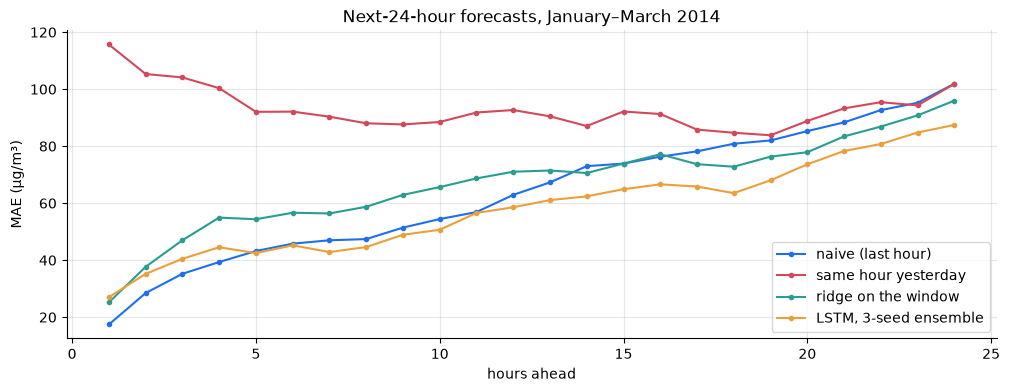

In [12]:
naive_h = np.repeat(hourly_pm.to_numpy()[h_positions][:, None], HH, axis=1)
yesterday_h = np.stack([hourly_pm.to_numpy()[p - HH + 1: p + 1] for p in h_positions])

h_scaler = Scaler().fit(Xh, Yh)
ridge_h = Ridge(alpha=10.0).fit(h_scaler.x(Xh).reshape(len(Xh), -1), h_scaler.y(Yh))
ridge_fc = np.exp(h_scaler.y_back(ridge_h.predict(np.nan_to_num(h_scaler.x(Xh_test)).reshape(len(Xh_test), -1))))

def lstm_24(input_shape):
    inp = keras.Input(input_shape)
    x = layers.Dropout(0.2)(layers.LSTM(32)(inp))
    model = keras.Model(inp, layers.Dense(HH)(x))
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")
    return model

lstm_members = []
for seed in [0, 1, 2]:
    model, scaler, _ = train(lstm_24, Xh, Yh, seed, patience=8)
    scaled_inputs = np.nan_to_num(scaler.x(Xh_test)).astype("float32")      # untestable rows are ignored later
    lstm_members.append(scaler.y_back(model(scaled_inputs, training=False).numpy()))
lstm_fc = np.exp(np.mean(lstm_members, axis=0))

hourly_scores = pd.DataFrame({
    "naive (last hour)": hourly_mae(naive_h),
    "same hour yesterday": hourly_mae(yesterday_h),
    "ridge on the window": hourly_mae(ridge_fc),
    "LSTM, 3-seed ensemble": hourly_mae(lstm_fc),
})
ax = hourly_scores.plot(marker=".", title="Next-24-hour forecasts, January–March 2014", xlabel="hours ahead", ylabel="MAE (µg/m³)")
hourly_scores.iloc[[0, 5, 11, 17, 23]].round(1)

The hourly task has its own shape:

- **For the next hour or two, naive is very hard to beat.** Air quality barely changes within an hour. The multi-output models spread their effort over all 24 hours, and give up some of that first-hour precision.
- **"Same hour yesterday" is poor**, worst of all for the first hours. The daily cycle (chapter 01) is weak next to hour-to-hour persistence.
- **With more data, the LSTM earns its place.** It matches naive by about 6 hours ahead, and from half a day out it's clearly best, ahead of naive by roughly 4 to 17 µg/m³. It also beats **ridge on the same window at every horizon from 6 hours**, and ridge even trails naive at 6 and 12 hours.

That's the reverse of the daily result. Here there are about 4,700 training windows, and the dynamics are richer: the daily cycle unfolding hour by hour, and fronts arriving through the night. The flexible sequence model finds structure that a linear model on raw inputs misses. It's one winter quarter and three seeds, so treat it as a first result rather than a verdict. But it shows the conditions under which deep learning pays off, which section 7 sums up.

---
## 7. When is deep learning worth it?

Our result is typical for **a single, short, noisy series**. Deep learning tends to earn its place when some of these hold:

| Deep learning helps when… | Our case |
|---|---|
| **lots of data**: long histories, high frequency, or **many related series** trained together (a *global* model) | 1 series, about 1,400 daily examples |
| rich, **high-dimensional inputs** (images, text, many sensors) whose useful features are hard to hand-craft | 11 inputs per day, which we understand well |
| complex **non-linear interactions** that simple features can't express | effects close to linear on the log scale |
| compute and time for **ensembles and tuning** are affordable | yes, but the gains are small |

Large **pretrained time-series foundation models** push the "lots of data" idea furthest: they're trained on vast collections of public series and then applied to new ones. Whatever the model, the discipline of this chapter carries over. That means honest windows, training-only scaling, time-ordered validation, several seeds, and a like-for-like comparison with strong simple models.

---
## Exercises

### Exercise 1: Watch overfitting happen
Train the LSTM on `X_example, Y_example` for a fixed 150 epochs, with **no** early stopping (hint: pass `patience=10_000` to `train`). Plot the training and validation losses. At which epoch is validation loss lowest, and how much worse is it by epoch 150?

<details><summary>Solution</summary>

```python
_, _, long_history = train(lstm, X_example, Y_example, seed=0, max_epochs=150, patience=10_000)
long_curves = pd.DataFrame({"training": long_history.history["loss"], "validation": long_history.history["val_loss"]})
best_epoch = long_curves["validation"].idxmin()
long_curves.plot(title="150 epochs without early stopping", xlabel="epoch", ylabel="loss")
print(f"best validation loss {long_curves['validation'].min():.3f} at epoch {best_epoch}; "
      f"at epoch 150 it's {long_curves['validation'].iloc[-1]:.3f}")
```
The training loss falls steadily for all 150 epochs, while the validation loss reaches its minimum early and then rises as the network memorises the training period. The gap between the two curves is overfitting made visible. Without early stopping, you'd deploy the epoch-150 model and get worse forecasts.
</details>

### Exercise 2: How big should the ensemble be?
Using the saved per-seed forecasts in `lstm_runs`, score ensembles of the first 1, 2, 3, 4 and 5 seeds. Plot the average MAE over horizons against ensemble size.

<details><summary>Solution</summary>

```python
sizes = range(1, len(SEEDS) + 1)
by_size = pd.Series({k: score(ensemble(lstm_runs, SEEDS[:k]))["MAE"].mean() for k in sizes},
                    name="average MAE over 7 horizons")
by_size.plot(marker="o", title="LSTM ensemble size vs. error", xlabel="number of seeds averaged", ylabel="MAE (µg/m³)")
by_size
```
The curve isn't smooth, and that's the lesson. Adding seed 1, the worst single run in section 4, makes the two-member ensemble *worse* than seed 0 alone. From three members on, the average settles and stops depending much on any single seed. With only a few members, the ensemble still inherits the luck of the seeds you happened to draw. So use more members than seems necessary, and to measure the effect of ensemble size properly, average over many random orderings of the seeds. Even so, ensembling remains the cheapest reliable improvement for any neural network.
</details>

### Exercise 3: How much history should the network see?
Rebuild the windows with `L = 7` and then `L = 56` days. Change `L` and re-run the cells in section 1 so that `window_at` and `training_windows` pick up the new length. Train 2-seed LSTM ensembles for each and compare with `L = 28`.

<details><summary>Solution</summary>

```python
results = {"L = 28 (5 seeds)": seed_scores["LSTM, 5-seed ensemble"]}
for window_length in [7, 56]:
    L = window_length                                   # window_at / training_windows read the global L
    runs = network_backtest(lstm, [0, 1])
    results[f"L = {window_length} (2 seeds)"] = score(ensemble(runs, [0, 1]))["MAE"]
L = 28                                                  # restore
pd.DataFrame(results)
```
A **7-day** window is noticeably worse at day 1, while **56 days** performs about the same as 28. So a week of history isn't quite enough, even though PM2.5 forgets within days (chapter 03). The network uses the longer window to judge the *recent level*, the job the 30-day mean does in chapter 09's features. Beyond about a month, more history adds nothing. With only two seeds per run, part of any difference is seed noise (section 4), and the 5-seed baseline isn't a perfectly fair comparison, but the 7-day shortfall at day 1 is larger than that noise.
</details>

### Exercise 4: Does refit frequency matter?
The networks were refitted quarterly, while chapter 09's models were refitted monthly. Refit chapter 09's ridge features **quarterly** and compare with the monthly version. Is the comparison in section 4 fair?

<details><summary>Solution</summary>

```python
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

quarterly = {}
for h in range(1, H + 1):
    X = tsutils.ml_features(y, weather, h)
    target = np.log(actual).shift(-h)
    complete = X.notna().all(axis=1) & target.notna()
    for _, quarter_origins in quarters:
        usable = complete & (X.index <= quarter_origins.iloc[0] - pd.Timedelta(days=h))
        model = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(X[usable], target[usable])
        preds = np.exp(model.predict(X.loc[quarter_origins.to_numpy()]))
        quarterly.update({(o, h): p for o, p in zip(quarter_origins, preds)})

pd.DataFrame({"ridge, monthly refits (ch. 09)": board["Ridge, direct"], "ridge, quarterly refits": score(quarterly)["MAE"]})
```
The two are nearly identical. With years of history, adding one more month changes the fitted model very little, and the inputs are always current. So the networks' quarterly schedule doesn't explain their gap to ridge. The comparison is fair.
</details>

---
## Key takeaways

- Sequence models take **(samples, timesteps, features)** windows. Train only on windows whose **targets were all known** at the refit date, and scale with **training statistics only**.
- **Time-ordered validation with early stopping** is essential. On small data, networks start overfitting within a few epochs.
- **Random seeds matter**: single LSTM runs differed by several µg/m³, more than many model-to-model differences. **Ensembling** several seeds is cheap and reliable. Never report a single run.
- A 5-seed LSTM ensemble learned the AR(2)-level memory from raw data, and the smaller **SimpleRNN did better at day 1**, but **chapter 09's feature-based ridge still wins at days 1–2**. On one short series, **better inputs beat a bigger model**.
- On the **hourly** next-24-hours task, with about 4,700 training windows, the LSTM beat both naive and ridge from about 6–12 hours ahead. More data and richer dynamics tip the balance.
- Deep learning pays off with **much more data** (long, high-frequency or many related series), **complex inputs**, or **genuine non-linearity**. Always compare like-for-like against strong simple models.

**Next:** *11 · Capstone*. We finally open the locked 2015 data and run the best model from each family through a single, final, honest comparison.